In [1]:
! which python

/home/zhanyu/anaconda3/envs/machine/bin/python


## 加载CSV文件

In [2]:
import pandas as pd
import numpy as np

In [3]:


# # 读取CSV文件
# # /Users/zhanyu/code/data-hh/海航系销售结果数据
# df = pd.read_csv('../../data-hh/海航系销售结果数据/hh_result_23-1-3.csv')

# # 显示前两行数据以确保正确加载
# print(df.shape)
# print(df.head(5))

In [4]:
import pandas as pd
import glob
import os

# 指定目录路径
directory_path = '../../data-hh/海航系销售结果数据/'

# 使用 glob 匹配所有 CSV 文件
csv_files = glob.glob(os.path.join(directory_path, "*.csv"))

# 检查匹配到的 CSV 文件列表
print("找到的 CSV 文件:")
print(csv_files)

# 读取所有 CSV 文件并合并为一个 DataFrame
dataframes = []  # 用于存储每个 CSV 文件的 DataFrame
for file in csv_files:
    print(f"正在读取文件: {file}")
    df = pd.read_csv(file)
    dataframes.append(df)

# 合并所有 DataFrame（可根据需要选择拼接方式）
df = pd.concat(dataframes, ignore_index=True)

# 显示合并后的数据形状和前几行
print("合并后的数据形状:", df.shape)
print(df.head())


找到的 CSV 文件:
['../../data-hh/海航系销售结果数据/mid_flt_allmkt_segment_result_sale_tmp_202410221659.csv', '../../data-hh/海航系销售结果数据/mid_flt_allmkt_segment_result_sale_tmp_202410221656-1729587422763.csv', '../../data-hh/海航系销售结果数据/mid_flt_allmkt_segment_result_sale_tmp_202410221700.csv', '../../data-hh/海航系销售结果数据/mid_flt_allmkt_segment_result_sale_tmp_202410221701.csv', '../../data-hh/海航系销售结果数据/mid_flt_allmkt_segment_result_sale_tmp_202410221655.csv', '../../data-hh/海航系销售结果数据/mid_flt_allmkt_segment_result_sale_tmp_202410221653.csv', '../../data-hh/海航系销售结果数据/mid_flt_allmkt_segment_result_sale_tmp_202410221656.csv', '../../data-hh/海航系销售结果数据/mid_flt_allmkt_segment_result_sale_tmp_202410221657.csv']
正在读取文件: ../../data-hh/海航系销售结果数据/mid_flt_allmkt_segment_result_sale_tmp_202410221659.csv
正在读取文件: ../../data-hh/海航系销售结果数据/mid_flt_allmkt_segment_result_sale_tmp_202410221656-1729587422763.csv
正在读取文件: ../../data-hh/海航系销售结果数据/mid_flt_allmkt_segment_result_sale_tmp_202410221700.csv
正在读取文件: ../../data-hh/海航系销售结果数据

## 拆分 flt_date 为 year, month, day, weekday

In [5]:


# 将 'flt_date' 列转换为 datetime 格式
df['flt_date'] = pd.to_datetime(df['flt_date'])

# 提取年、月、日和星期几
df['year'] = df['flt_date'].dt.year
df['month'] = df['flt_date'].dt.month
df['day'] = df['flt_date'].dt.day
df['weekday'] = df['flt_date'].dt.weekday  # 0 = Monday, 6 = Sunday

# 删除原始的 'flt_date' 字段
df = df.drop(columns=['flt_date'])

# 删除2024年6月的数据
df = df[~((df['year'] == 2024) & (df['month'] == 6))]

# 查看结果
print(df.head(5))

                     segment        flt_no bd_type  dep_time  cap aircraft  \
0  xIqe+QQIQXQ=-AfKac4FzdXs=  /O2MVlG1lP0=      窄体  07:00:00  194      321   
1  So/c8CkA/Xs=-xIqe+QQIQXQ=  azmQzfSK1Vs=      窄体  15:35:00    0      321   
2  1/9nd1jNCE0=-/qxKZMQeBus=  NcjJIwuZ7EM=      窄体  17:00:00  194      321   
3  /qxKZMQeBus=-1/9nd1jNCE0=  OPrfHrOAYb4=      窄体  19:45:00  194      321   
4  1/9nd1jNCE0=-grkgazDvJmY=  BzH6ckq374w=      窄体  06:55:00  194      321   

   legs  leg_no  duration   tkt_rev  pax             a             b  \
0     3       1      2.42  100166.0  102  xIqe+QQIQXQ=  AfKac4FzdXs=   
1     3       3      0.00   39657.0   31  So/c8CkA/Xs=  AfKac4FzdXs=   
2     1       1      1.73  122852.0  136  1/9nd1jNCE0=  /qxKZMQeBus=   
3     1       1      1.95   82827.0  128  /qxKZMQeBus=  1/9nd1jNCE0=   
4     1       1      3.35  112572.0  143  1/9nd1jNCE0=  grkgazDvJmY=   

              c  year  month  day  weekday  
0  So/c8CkA/Xs=  2024      1    1        0  
1  xIqe+

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6182158 entries, 0 to 6546416
Data columns (total 18 columns):
 #   Column    Dtype  
---  ------    -----  
 0   segment   object 
 1   flt_no    object 
 2   bd_type   object 
 3   dep_time  object 
 4   cap       int64  
 5   aircraft  object 
 6   legs      int64  
 7   leg_no    int64  
 8   duration  float64
 9   tkt_rev   float64
 10  pax       int64  
 11  a         object 
 12  b         object 
 13  c         object 
 14  year      int32  
 15  month     int32  
 16  day       int32  
 17  weekday   int32  
dtypes: float64(2), int32(4), int64(4), object(8)
memory usage: 801.8+ MB


## 拆分 dep_time 为 hour, minute, second

In [7]:
# 拆分 'dep_time' 字段
df[['hour', 'minute', 'second']] = df['dep_time'].str.split(':', expand=True)

# 将拆分的结果转换为整数
df['hour'] = df['hour'].astype(int)
df['minute'] = df['minute'].astype(int)
df['second'] = df['second'].astype(int)

# 删除原始的 'dep_time' 字段
df = df.drop(columns=['dep_time'])

# 查看结果
print(df.head(5))

                     segment        flt_no bd_type  cap aircraft  legs  \
0  xIqe+QQIQXQ=-AfKac4FzdXs=  /O2MVlG1lP0=      窄体  194      321     3   
1  So/c8CkA/Xs=-xIqe+QQIQXQ=  azmQzfSK1Vs=      窄体    0      321     3   
2  1/9nd1jNCE0=-/qxKZMQeBus=  NcjJIwuZ7EM=      窄体  194      321     1   
3  /qxKZMQeBus=-1/9nd1jNCE0=  OPrfHrOAYb4=      窄体  194      321     1   
4  1/9nd1jNCE0=-grkgazDvJmY=  BzH6ckq374w=      窄体  194      321     1   

   leg_no  duration   tkt_rev  pax             a             b             c  \
0       1      2.42  100166.0  102  xIqe+QQIQXQ=  AfKac4FzdXs=  So/c8CkA/Xs=   
1       3      0.00   39657.0   31  So/c8CkA/Xs=  AfKac4FzdXs=  xIqe+QQIQXQ=   
2       1      1.73  122852.0  136  1/9nd1jNCE0=  /qxKZMQeBus=           NaN   
3       1      1.95   82827.0  128  /qxKZMQeBus=  1/9nd1jNCE0=           NaN   
4       1      3.35  112572.0  143  1/9nd1jNCE0=  grkgazDvJmY=           NaN   

   year  month  day  weekday  hour  minute  second  
0  2024      1    1  

## 拆分 segment 为 from 和 to

In [8]:
# 拆分 'segment' 字段为 'from' 和 'to'
df[['from', 'to']] = df['segment'].str.split('-', expand=True)

# 删除原始的 'segment' 字段
df = df.drop(columns=['segment'])

# 查看结果
print(df.head(10))

         flt_no bd_type  cap aircraft  legs  leg_no  duration   tkt_rev  pax  \
0  /O2MVlG1lP0=      窄体  194      321     3       1      2.42  100166.0  102   
1  azmQzfSK1Vs=      窄体    0      321     3       3      0.00   39657.0   31   
2  NcjJIwuZ7EM=      窄体  194      321     1       1      1.73  122852.0  136   
3  OPrfHrOAYb4=      窄体  194      321     1       1      1.95   82827.0  128   
4  BzH6ckq374w=      窄体  194      321     1       1      3.35  112572.0  143   
5  qOb5e5EUEzk=      窄体  194      321     1       1      3.30  200746.0  157   
6  HsnT2/CkvTA=      窄体  164      320     1       1      1.53   49792.0   99   
7  ioog+2s5D9A=      窄体  164      320     1       1      1.67   34456.0   74   
8  xukJJX097WU=      窄体  164      320     1       1      1.88   56437.0  123   
9  EAw56WDndsQ=      窄体  132      319     1       1      2.05   41749.0   83   

              a  ...             c  year  month  day  weekday  hour  minute  \
0  xIqe+QQIQXQ=  ...  So/c8CkA/Xs=  2024

## 删除pax异常的行

In [9]:
# 统计 'pax' 字段中缺失值的行数
missing_pax = df[df['pax'].isna()]

# 统计 'pax' 字段中0值的行数
zero_pax = df[df['pax'] == 0]

# 输出统计结果
num_missing = missing_pax.shape[0]
num_zero = zero_pax.shape[0]

print(df.shape[0])
print(f"缺失值的行数: {num_missing}")
print(f"为0的行数: {num_zero}")

6182158
缺失值的行数: 0
为0的行数: 155335


In [10]:
# 删除 'pax' 字段为缺失值或为0的行
df = df.dropna(subset=['pax'])  # 删除pax列中的缺失值行
df = df[df['pax'] != 0]  # 删除pax列中为0的行

# 查看删除后的DataFrame行数
num_rows_after_cleanup = df.shape[0]
print(f"删除缺失值或为0的行后，DataFrame一共有 {num_rows_after_cleanup} 行")

删除缺失值或为0的行后，DataFrame一共有 6026823 行


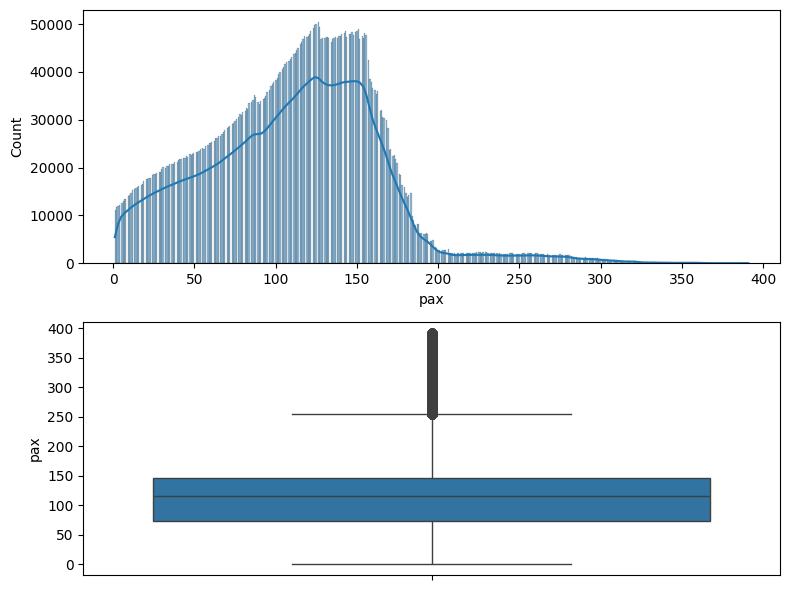

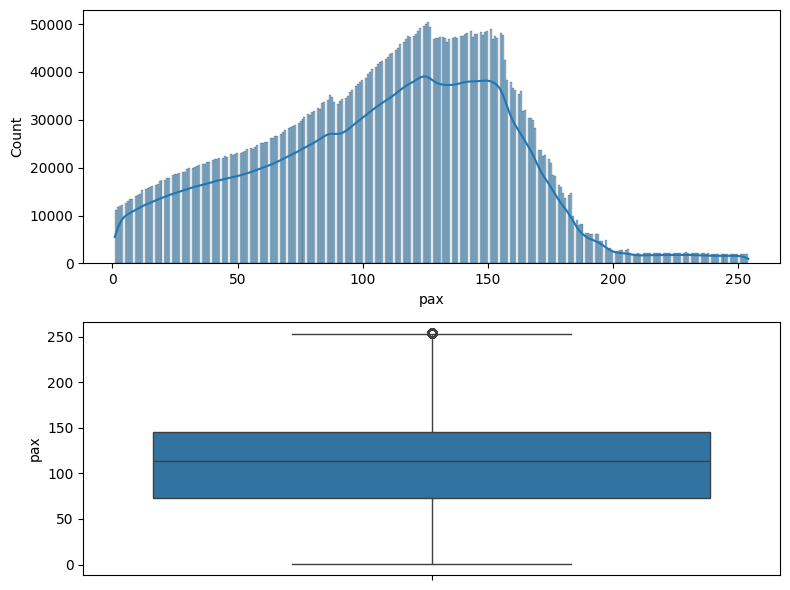

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def remove_outliers(data, col):
    """删除指定列中的异常值"""
    Q1 = data[col].quantile(0.25)  # 第1四分位数
    Q3 = data[col].quantile(0.75)  # 第3四分位数
    IQR = Q3 - Q1  # 四分位距
    lower_bound = Q1 - 1.5 * IQR  # 下限
    upper_bound = Q3 + 1.5 * IQR  # 上限
    
    # 筛选出范围内的数据
    filtered_data = data[(data[col] >= lower_bound) & (data[col] <= upper_bound)]
    return filtered_data

def plot(data, col):
    """绘制指定列的分布图和箱型图"""
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6))
    sns.histplot(data[col], kde=True, ax=ax1)  # 替换 distplot 为 histplot
    sns.boxplot(data[col], ax=ax2)
    plt.tight_layout()
    plt.show()

# 绘制过滤后的数据分布图和箱型图
plot(df, 'pax')
# 示例数据框
# 假设 df 是你的数据框
# 删除 pax 列中的异常值
df = remove_outliers(df, 'pax')

# 绘制过滤后的数据分布图和箱型图
plot(df, 'pax')

## 处理aircraft

In [12]:
# 查看 'cap' 列中每个元素的数据类型
print(df['aircraft'].apply(type).value_counts())

aircraft
<class 'str'>      5933991
<class 'float'>        101
Name: count, dtype: int64


In [13]:
# 统计 'pax' 字段中缺失值的行数
missing_pax = df[df['aircraft'].isna()]

# 统计 'pax' 字段中0值的行数
zero_pax = df[df['aircraft'] == 0]

# 输出统计结果
num_missing = missing_pax.shape[0]
num_zero = zero_pax.shape[0]

print(df.shape[0])
print(f"缺失值的行数: {num_missing}")
print(f"为0的行数: {num_zero}")

5934092
缺失值的行数: 101
为0的行数: 0


In [14]:
# 将 cap 列转换为 Pandas 的 Int64 类型，这种类型支持 NaN 值
# 将 'aircraft' 列转换为字符串类型
# 用 'Unknown' 填充 NaN 值
df['aircraft'] = df['aircraft'].fillna('Unknown')
df['aircraft'] = df['aircraft'].astype(str)

In [15]:
# 查看 'cap' 列中每个元素的数据类型
print(df['aircraft'].apply(type).value_counts())

aircraft
<class 'str'>    5934092
Name: count, dtype: int64


## 处理cap

In [16]:
# 查看 'cap' 列中每个元素的数据类型
print(df['cap'].apply(type).value_counts())

cap
<class 'int'>    5934092
Name: count, dtype: int64


In [17]:
# 统计 'pax' 字段中缺失值的行数
missing_pax = df[df['cap'].isna()]

# 统计 'pax' 字段中0值的行数
zero_pax = df[df['cap'] == 0]

# 输出统计结果
num_missing = missing_pax.shape[0]
num_zero = zero_pax.shape[0]

print(df.shape[0])
print(f"缺失值的行数: {num_missing}")
print(f"为0的行数: {num_zero}")

# 将 'cap' 字段中为0的值修改为 NaN
df.loc[df['cap'] == 0, 'cap'] = np.nan

# 将 'cap' 字段转换为字符串类型
df['cap'] = df['cap'].astype(str)

5934092
缺失值的行数: 0
为0的行数: 769585


In [18]:
# 查看 'cap' 列中每个元素的数据类型
print(df['cap'].apply(type).value_counts())
print(df['aircraft'].apply(type).value_counts())

cap
<class 'str'>    5934092
Name: count, dtype: int64
aircraft
<class 'str'>    5934092
Name: count, dtype: int64


## 处理duration（待做）

In [19]:
# 将 'duration' 列中值为 0 的部分替换为 NaN
df.loc[df['duration'] == 0, 'duration'] = np.nan

## 处理tkt_rev

In [20]:
# 统计 'unit_price' 列中为 0 的行数
zero_count = (df['tkt_rev'] == 0).sum()

# 统计 'unit_price' 列中为 NaN 的行数
nan_count = df['tkt_rev'].isna().sum()

# 输出结果
print(f"tkt_rev 列中为 0 的行数: {zero_count}")
print(f"tkt_rev 列中为 NaN 的行数: {nan_count}")

tkt_rev 列中为 0 的行数: 1096
tkt_rev 列中为 NaN 的行数: 0


In [21]:
df = df[df['tkt_rev'] != 0]

# 计算单价 'unit_price'，即 tkt_rev 除以 pax
df['unit_price'] = df['tkt_rev'] / df['pax']

# 删除 'tkt_rev' 列
df = df.drop(columns=['tkt_rev'])

## 保存文件

In [22]:
# 保存处理后的数据到新的CSV文件
df.to_csv('../../data-hh/my/hh_result/result_all.csv', index=False)

In [23]:
# # 将数据按时间段分开
# df_2023_2024_05 = df[(df['year'] == 2023) | ((df['year'] == 2024) & (df['month'] <= 5))]
# df_2024_06 = df[(df['year'] == 2024) & (df['month'] == 6)]

# # 保存2023年1月到2024年5月的数据
# df_2023_2024_05.to_csv('../../data-hh/my/hh_result/result_2023_2024_05.csv', index=False)

# # 保存2024年6月的数据
# df_2024_06.to_csv('../../data-hh/my/hh_result/result_2024_06.csv', index=False)

## 统计航段价格信息

In [24]:
# 计算每对城市间直航航班的价格统计信息
price_stats = df.groupby(['from', 'to']).agg({
    'unit_price': ['mean', 'std', 'count']
}).round(2)

# 重命名列
price_stats.columns = ['平均价格', '价格标准差', '航班数量']

# 对只有一趟航班的航线,将标准差设为平均价格的十分之一
single_flight_routes = price_stats['航班数量'] == 1
price_stats.loc[single_flight_routes, '价格标准差'] = price_stats.loc[single_flight_routes, '平均价格'] / 10

# 按平均价格降序排序
price_stats = price_stats.sort_values('平均价格', ascending=False)

# 显示结果
print("每对城市间直航航班的价格统计：")
print(price_stats)

# 可选：保存结果到CSV文件
price_stats.to_csv('../../data-hh/my/hh_result/route_price_stats.csv')

# 输出一些基本统计信息
print("\n基本统计信息：")
print(f"航线总数：{len(price_stats)}")
print(f"最高平均票价航线：{price_stats['平均价格'].max():.2f}")
print(f"最低平均票价航线：{price_stats['平均价格'].min():.2f}")
print(f"最大标准差航线：{price_stats['价格标准差'].max():.2f}")

每对城市间直航航班的价格统计：
                              平均价格     价格标准差  航班数量
from         to                                   
yypkiQCX5lk= nlFV4N9et20=  4630.00   463.000     1
nlFV4N9et20= yypkiQCX5lk=  4594.62   360.170     6
t0yIIzgLFLs= 0J4jz5aCatU=  4567.94  3671.760     6
So/c8CkA/Xs= ZCvDTbZuS8Q=  4500.00   450.000     1
Y50ETJ8qYSE= EIsXRbFUH34=  4460.00   446.000     1
...                            ...       ...   ...
wbf1sxPhwNM= iX2Pe2pxiqQ=    99.19    14.510    73
7iTiE9huQwg= pfMOg0V8Pys=    99.00     0.000     6
2jt80AsNp3c= Y50ETJ8qYSE=    95.69    44.900    31
Y50ETJ8qYSE= 2jt80AsNp3c=    86.86    42.310    30
LIrnUnlANso= 2jt80AsNp3c=    26.48     2.648     1

[7977 rows x 3 columns]

基本统计信息：
航线总数：7977
最高平均票价航线：4630.00
最低平均票价航线：26.48
最大标准差航线：5296.02
